# 图特征与 Global 策略的分层分析

这个笔记本把分析分成两层：

1. 被试层面
- 不同被试的平均策略是否一致
- 同一个被试跨 round 的策略是否稳定

2. 地图层面
- 在同一张图上，不同被试的策略是否一致
- 图的结构特征如何与被试策略相关

核心策略指标来自 `global_stats.py`：
- `start_dist_to_center`：起点到地图中心的距离
- `mean_step_dist`：连续两步着色区域质心之间的平均距离
- `neighbor_transition_rate`：连续两步是否在相邻区域之间移动的比例

图特征来自 `graph_analysis.py`，例如：节点数、密度、直径、平均最短路、聚类系数、面积离散度等。

In [21]:
import os
os.environ.setdefault('OMP_NUM_THREADS', '1')
os.environ.setdefault('OPENBLAS_NUM_THREADS', '1')
os.environ.setdefault('MKL_NUM_THREADS', '1')
os.environ.setdefault('VECLIB_MAXIMUM_THREADS', '1')
os.environ.setdefault('NUMEXPR_NUM_THREADS', '1')
os.environ.setdefault('KMP_DUPLICATE_LIB_OK', 'TRUE')

import sys
import glob as glob_module
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr
from IPython.display import display

try:
    import pandas as pd
except ImportError:
    raise RuntimeError('需要 pandas 才能运行该 notebook。')

NOTEBOOK_DIR = Path.cwd()
if not (NOTEBOOK_DIR / 'global_stats.py').exists():
    NOTEBOOK_DIR = Path('model code/fitting').resolve()

sys.path.insert(0, str(NOTEBOOK_DIR))

from fit_softmax import build_all_maps
from global_stats import analyze_participant
from graph_analysis import summarize_round, rebuild_map

import platform
if platform.system() == 'Darwin':
    plt.rcParams['font.sans-serif'] = ['PingFang SC', 'Heiti TC', 'STHeiti', 'Arial Unicode MS']
elif platform.system() == 'Windows':
    plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei']
else:
    plt.rcParams['font.sans-serif'] = ['Noto Sans CJK SC', 'WenQuanYi Zen Hei', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False

formal_rounds = [str(i) for i in range(1, 11)]

def safe_spearman(x, y):
    x = np.asarray(x)
    y = np.asarray(y)
    if len(x) < 3 or np.all(x == x[0]) or np.all(y == y[0]):
        return np.nan, np.nan
    res = spearmanr(x, y)
    return float(res.statistic), float(res.pvalue)

def safe_pearson(x, y):
    x = np.asarray(x)
    y = np.asarray(y)
    if len(x) < 3 or np.all(x == x[0]) or np.all(y == y[0]):
        return np.nan, np.nan
    r, p = pearsonr(x, y)
    return float(r), float(p)

def add_fit_line(ax, x, y, color='black'):
    x = np.asarray(x)
    y = np.asarray(y)
    if len(x) < 2 or np.allclose(x, x[0]):
        return
    coef = np.polyfit(x, y, 1)
    xs = np.linspace(x.min(), x.max(), 100)
    ys = coef[0] * xs + coef[1]
    ax.plot(xs, ys, color=color, linestyle='--', linewidth=1.5)

def zscore_within_group(df, group_col, value_col):
    def _z(s):
        std = s.std(ddof=0)
        if std == 0 or np.isnan(std):
            return s * 0
        return (s - s.mean()) / std
    return df.groupby(group_col)[value_col].transform(_z)

def standardize_matrix(X):
    X = np.asarray(X, dtype=float)
    mu = X.mean(axis=0)
    sigma = X.std(axis=0, ddof=0)
    sigma[sigma == 0] = 1.0
    return (X - mu) / sigma, mu, sigma

def kmeans_numpy(X, n_clusters, n_init=20, random_state=0, max_iter=200):
    rng = np.random.default_rng(random_state)
    X = np.asarray(X, dtype=float)
    best_labels = None
    best_centers = None
    best_inertia = np.inf
    n = len(X)

    for _ in range(n_init):
        indices = rng.choice(n, size=n_clusters, replace=False)
        centers = X[indices].copy()

        for _ in range(max_iter):
            d2 = ((X[:, None, :] - centers[None, :, :]) ** 2).sum(axis=2)
            labels = d2.argmin(axis=1)
            new_centers = centers.copy()
            for k in range(n_clusters):
                members = X[labels == k]
                if len(members) == 0:
                    new_centers[k] = X[rng.integers(0, n)]
                else:
                    new_centers[k] = members.mean(axis=0)
            if np.allclose(new_centers, centers):
                centers = new_centers
                break
            centers = new_centers

        d2 = ((X[:, None, :] - centers[None, :, :]) ** 2).sum(axis=2)
        labels = d2.argmin(axis=1)
        inertia = d2[np.arange(n), labels].sum()
        if inertia < best_inertia:
            best_inertia = inertia
            best_labels = labels.copy()
            best_centers = centers.copy()

    return {'labels': best_labels, 'centers': best_centers, 'inertia': float(best_inertia)}

def silhouette_score_numpy(X, labels):
    X = np.asarray(X, dtype=float)
    labels = np.asarray(labels)
    unique = np.unique(labels)
    if len(unique) < 2:
        return np.nan
    dists = np.sqrt(((X[:, None, :] - X[None, :, :]) ** 2).sum(axis=2))
    sil = []
    for i in range(len(X)):
        own = labels[i]
        own_mask = labels == own
        own_mask[i] = False
        a = dists[i, own_mask].mean() if own_mask.any() else 0.0
        b_vals = []
        for other in unique:
            if other == own:
                continue
            other_mask = labels == other
            if other_mask.any():
                b_vals.append(dists[i, other_mask].mean())
        b = min(b_vals) if b_vals else 0.0
        sil.append((b - a) / max(a, b) if max(a, b) > 0 else 0.0)
    return float(np.mean(sil))

def pca_numpy(X, n_components=2):
    X = np.asarray(X, dtype=float)
    Xc = X - X.mean(axis=0)
    U, S, Vt = np.linalg.svd(Xc, full_matrices=False)
    coords = Xc @ Vt[:n_components].T
    var = (S ** 2) / max(len(X) - 1, 1)
    ratio = var / var.sum() if var.sum() > 0 else np.zeros_like(var)
    return coords, ratio[:n_components]


## 1. 数据加载：图特征表与策略表

In [22]:
maps = build_all_maps()

graph_rows = []
for rnd in formal_rounds:
    _, regions, adjacency = rebuild_map(rnd)
    row = summarize_round(rnd, regions, adjacency)
    row['round_num'] = int(rnd)
    graph_rows.append(row)
graph_df = pd.DataFrame(graph_rows).sort_values('round_num').reset_index(drop=True)

data_dir = (NOTEBOOK_DIR / '..' / 'data').resolve()
csv_files = sorted(glob_module.glob(str(data_dir / 'data_*.csv')))

strategy_rows = []
for filepath in csv_files:
    participant = Path(filepath).stem.replace('data_', '')
    result = analyze_participant(filepath, maps)
    if result is None:
        continue
    start_map = {row['round']: row for row in result['starting_points']}
    coherence_map = {row['round']: row for row in result['spatial_coherence']}
    for rnd in formal_rounds:
        if rnd not in start_map or rnd not in coherence_map:
            continue
        strategy_rows.append({
            'participant': participant,
            'round': rnd,
            'round_num': int(rnd),
            'start_dist_to_center': start_map[rnd]['dist_to_center'],
            'start_row': start_map[rnd]['centroid_row'],
            'start_col': start_map[rnd]['centroid_col'],
            'mean_step_dist': coherence_map[rnd]['mean_step_dist'],
            'std_step_dist': coherence_map[rnd]['std_step_dist'],
            'median_step_dist': coherence_map[rnd]['median_step_dist'],
            'neighbor_transition_rate': coherence_map[rnd]['neighbor_transition_rate'],
            'n_steps': coherence_map[rnd]['n_steps'],
        })

strategy_df = pd.DataFrame(strategy_rows).sort_values(['participant', 'round_num']).reset_index(drop=True)
analysis_df = strategy_df.merge(graph_df, on=['round', 'round_num'], how='left').sort_values(['participant', 'round_num']).reset_index(drop=True)

print(f'被试数: {analysis_df["participant"].nunique()}')
print(f'正式 round 数: {analysis_df["round"].nunique()}')
print(f'分析表大小: {analysis_df.shape}')
display(analysis_df[['participant', 'round', 'start_dist_to_center', 'mean_step_dist', 'neighbor_transition_rate', 'nodes', 'density', 'diameter']].head())

被试数: 17
正式 round 数: 10
分析表大小: (170, 47)


,participant,round,start_dist_to_center,mean_step_dist,neighbor_transition_rate,nodes,density,diameter
0,0,1,9.060369,7.750469,0.090909,20,0.236842,5
1,0,2,10.016986,6.913978,0.230769,23,0.213439,5
2,0,3,10.124228,7.093984,0.000000,26,0.178462,6
3,0,4,10.318538,6.629861,0.100000,28,0.169312,6
4,0,5,10.494708,5.982953,0.194444,31,0.148387,6


## 2. 被试层面：不同被试之间的平均策略是否一致

这里先把每个被试在 10 个正式 round 上的行为做平均。这样我们回答的是：
- 谁更偏向从中心附近开始
- 谁更倾向于大跨度跳跃
- 谁更倾向于沿相邻区域连续推进

In [23]:
participant_profile_df = (
    analysis_df.groupby('participant', as_index=False)
    .agg(
        rounds=('round', 'nunique'),
        avg_start_dist=('start_dist_to_center', 'mean'),
        sd_start_dist=('start_dist_to_center', 'std'),
        avg_mean_step_dist=('mean_step_dist', 'mean'),
        sd_mean_step_dist=('mean_step_dist', 'std'),
        avg_neighbor_rate=('neighbor_transition_rate', 'mean'),
        sd_neighbor_rate=('neighbor_transition_rate', 'std'),
    )
    .sort_values('participant')
    .reset_index(drop=True)
)

display(participant_profile_df.round(3))

,participant,rounds,avg_start_dist,sd_start_dist,avg_mean_step_dist,sd_mean_step_dist,avg_neighbor_rate,sd_neighbor_rate
0,0,10,10.241,0.545,6.323,0.792,0.069,0.086
1,031,10,5.192,3.693,4.698,0.855,0.455,0.166
2,24,10,9.697,0.982,5.185,1.033,0.412,0.304
3,311,10,10.146,0.516,3.619,0.677,0.756,0.075
4,Aa,10,1.305,0.729,4.242,0.718,0.746,0.143
5,FLT,10,9.246,0.884,4.230,0.666,0.635,0.082
6,Rex,10,3.550,3.811,4.333,0.568,0.600,0.106
7,Wangyudie,10,9.253,3.109,3.294,0.803,0.828,0.124
8,cmf,10,10.241,0.545,3.657,0.627,0.672,0.105
9,fzm,10,1.686,1.036,3.849,0.704,0.672,0.091


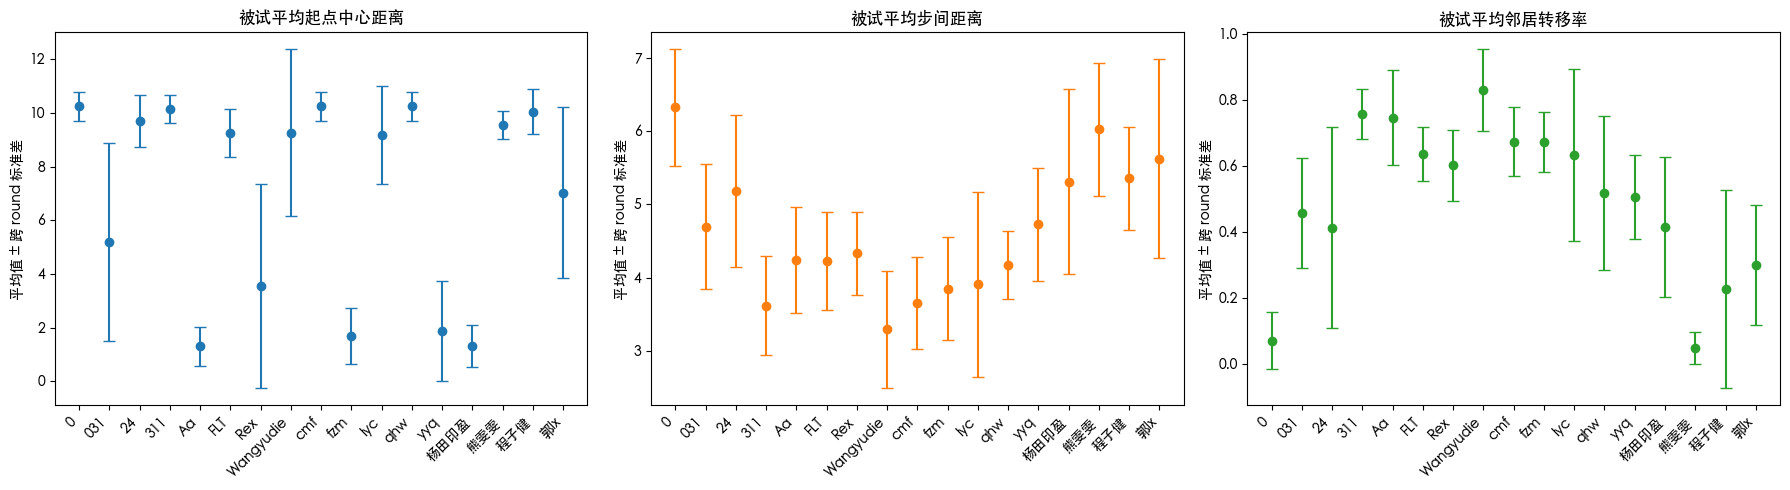

In [39]:
participants = participant_profile_df['participant'].tolist()
x = np.arange(len(participants))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].errorbar(x, participant_profile_df['avg_start_dist'], yerr=participant_profile_df['sd_start_dist'], fmt='o', capsize=4)
axes[0].set_title('被试平均起点中心距离')
axes[0].set_ylabel('平均值 ± 跨 round 标准差')
axes[0].set_xticks(x)
axes[0].set_xticklabels(participants, rotation=45, ha='right')

axes[1].errorbar(x, participant_profile_df['avg_mean_step_dist'], yerr=participant_profile_df['sd_mean_step_dist'], fmt='o', capsize=4, color='tab:orange')
axes[1].set_title('被试平均步间距离')
axes[1].set_ylabel('平均值 ± 跨 round 标准差')
axes[1].set_xticks(x)
axes[1].set_xticklabels(participants, rotation=45, ha='right')

axes[2].errorbar(x, participant_profile_df['avg_neighbor_rate'], yerr=participant_profile_df['sd_neighbor_rate'], fmt='o', capsize=4, color='tab:green')
axes[2].set_title('被试平均邻居转移率')
axes[2].set_ylabel('平均值 ± 跨 round 标准差')
axes[2].set_xticks(x)
axes[2].set_xticklabels(participants, rotation=45, ha='right')

plt.tight_layout()
plt.show()

**图解释**

- 每个点代表一个被试在全部正式 round 上的平均策略。
- 误差棒表示这个被试在不同 round 之间的波动大小。误差棒越短，说明这个人的策略越稳定。
- 左图值越小，表示越偏向从中心附近开始。
- 中图值越大，表示越倾向于在不同区域块之间做更大跨度的跳转。
- 右图值越大，表示越倾向于沿着当前区域附近连续推进，而不是频繁跳到远处。

### 2.1 聚类分析：平均策略是否形成不同类型

上面是逐个被试看平均值。这里进一步问：
- 这些被试能不能自然分成几类策略风格？
- 是否存在例如“中心起手型”“跳跃搜索型”“邻域推进型”这样的群体？

做法是：
- 用每个被试的三个平均策略指标作为特征
- 先标准化，再做 K-means 聚类
- 比较不同簇数的 silhouette score，选相对更合理的分组数

In [25]:
cluster_features = ['avg_start_dist', 'avg_mean_step_dist', 'avg_neighbor_rate']
cluster_X = participant_profile_df[cluster_features].to_numpy()
cluster_Xz, cluster_mu, cluster_sigma = standardize_matrix(cluster_X)

candidate_ks = list(range(2, min(6, len(participant_profile_df))))
cluster_eval_rows = []
best_model = None
best_k = None
best_score = -np.inf

for k in candidate_ks:
    model = kmeans_numpy(cluster_Xz, n_clusters=k, n_init=30, random_state=0)
    labels = model['labels']
    score = silhouette_score_numpy(cluster_Xz, labels)
    cluster_eval_rows.append({'k': k, 'silhouette_score': score})
    if score > best_score:
        best_score = score
        best_k = k
        best_model = model

cluster_eval_df = pd.DataFrame(cluster_eval_rows)
participant_profile_df['cluster'] = best_model['labels']

cluster_centers = pd.DataFrame(
    best_model['centers'] * cluster_sigma + cluster_mu,
    columns=cluster_features,
)
cluster_centers['cluster'] = range(best_k)

cluster_summary_df = (
    participant_profile_df.groupby('cluster', as_index=False)
    .agg(
        n_participants=('participant', 'count'),
        participants=('participant', lambda s: ', '.join(sorted(map(str, s)))),
        avg_start_dist=('avg_start_dist', 'mean'),
        avg_mean_step_dist=('avg_mean_step_dist', 'mean'),
        avg_neighbor_rate=('avg_neighbor_rate', 'mean'),
    )
    .sort_values('cluster')
    .reset_index(drop=True)
)

print(f'最佳簇数: k={best_k}, silhouette={best_score:.3f}')
display(cluster_eval_df.round(3))
display(participant_profile_df[['participant', 'avg_start_dist', 'avg_mean_step_dist', 'avg_neighbor_rate', 'cluster']].sort_values(['cluster', 'participant']).round(3))
display(cluster_summary_df.round(3))

最佳簇数: k=3, silhouette=0.547


,k,silhouette_score
0,2,0.433
1,3,0.547
2,4,0.481
3,5,0.489


,participant,avg_start_dist,avg_mean_step_dist,avg_neighbor_rate,cluster
0,0,10.241,6.323,0.069,0
2,24,9.697,5.185,0.412,0
14,熊雯雯,9.547,6.023,0.048,0
15,程子健,10.043,5.358,0.225,0
16,郭lx,7.030,5.625,0.298,0
3,311,10.146,3.619,0.756,1
5,FLT,9.246,4.230,0.635,1
7,Wangyudie,9.253,3.294,0.828,1
8,cmf,10.241,3.657,0.672,1
10,lyc,9.179,3.909,0.632,1


,cluster,n_participants,participants,avg_start_dist,avg_mean_step_dist,avg_neighbor_rate
0,0,5,"0, 24, 熊雯雯, 程子健, 郭lx",9.312,5.703,0.211
1,1,6,"311, FLT, Wangyudie, cmf, lyc, qhw",9.718,3.814,0.673
2,2,6,"031, Aa, Rex, fzm, yyq, 杨田印盈",2.487,4.526,0.565


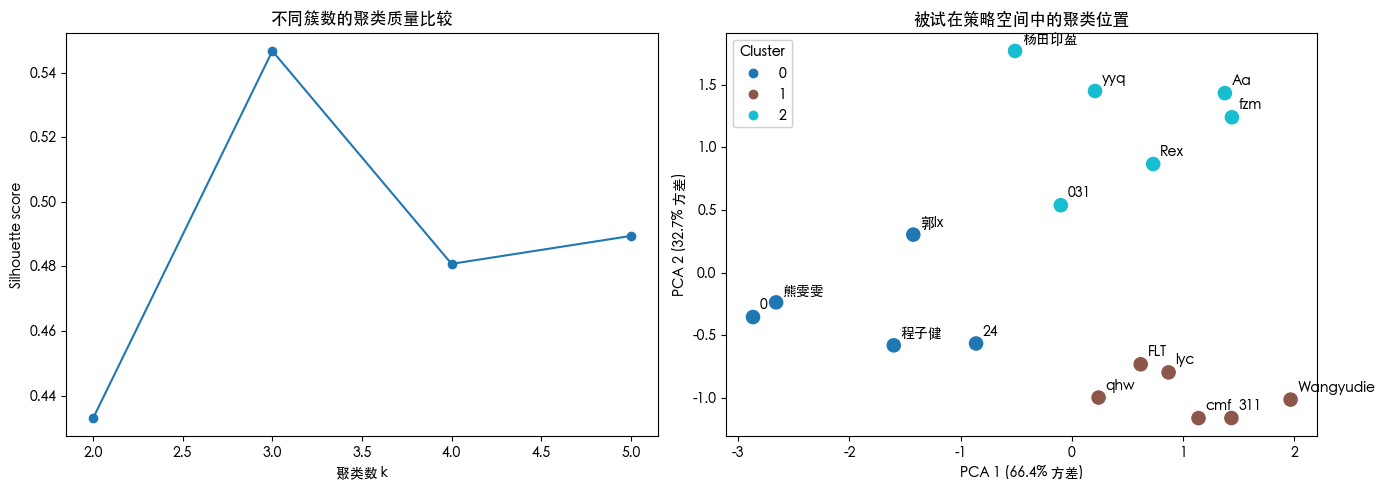

In [26]:
cluster_xy, cluster_pca_ratio = pca_numpy(cluster_Xz, n_components=2)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(cluster_eval_df['k'], cluster_eval_df['silhouette_score'], marker='o')
axes[0].set_xlabel('聚类数 k')
axes[0].set_ylabel('Silhouette score')
axes[0].set_title('不同簇数的聚类质量比较')

scatter = axes[1].scatter(cluster_xy[:, 0], cluster_xy[:, 1], c=participant_profile_df['cluster'], s=90, cmap='tab10')
for i, row in participant_profile_df.iterrows():
    axes[1].annotate(str(row['participant']), (cluster_xy[i, 0], cluster_xy[i, 1]), xytext=(5, 5), textcoords='offset points')
axes[1].set_xlabel(f'PCA 1 ({cluster_pca_ratio[0]:.1%} 方差)')
axes[1].set_ylabel(f'PCA 2 ({cluster_pca_ratio[1]:.1%} 方差)')
axes[1].set_title('被试在策略空间中的聚类位置')
legend1 = axes[1].legend(*scatter.legend_elements(), title='Cluster', loc='best')
axes[1].add_artist(legend1)

plt.tight_layout()
plt.show()

**图解释**

- 左图比较不同聚类数 `k` 的 silhouette score。这个值越高，说明分组后“组内更像、组间更不像”。
- 右图把每个被试放到一个二维策略空间里。距离近，表示三项平均策略更相似；距离远，表示整体策略风格更不同。
- 右图的颜色是聚类结果，同色被试看作同一类策略风格。
- 如果同色点聚得很紧，说明这一类人内部比较一致。
- 如果不同颜色之间明显分开，说明被试层面确实存在较稳定的策略类型，而不仅仅是连续的小差别。

## 3. 被试层面：同一个被试跨 round 是否稳定

这里把“稳定”分成两个部分：
- 波动大小：同一个人的标准差是否小
- 趋势漂移：随着 round 变难，这个人的策略是否系统性改变

In [40]:
stability_rows = []
for participant, sub in analysis_df.groupby('participant'):
    sub = sub.sort_values('round_num')
    start_rho, start_p = safe_spearman(sub['round_num'], sub['start_dist_to_center'])
    step_rho, step_p = safe_spearman(sub['round_num'], sub['mean_step_dist'])
    nbr_rho, nbr_p = safe_spearman(sub['round_num'], sub['neighbor_transition_rate'])
    stability_rows.append({
        'participant': participant,
        'start_sd': sub['start_dist_to_center'].std(ddof=1),
        'step_sd': sub['mean_step_dist'].std(ddof=1),
        'neighbor_sd': sub['neighbor_transition_rate'].std(ddof=1),
        'start_round_rho': start_rho,
        'step_round_rho': step_rho,
        'neighbor_round_rho': nbr_rho,
        'start_round_p': start_p,
        'step_round_p': step_p,
        'neighbor_round_p': nbr_p,
    })

stability_df = pd.DataFrame(stability_rows).sort_values('participant').reset_index(drop=True)
display(stability_df.round(3))

,participant,start_sd,step_sd,neighbor_sd,start_round_rho,step_round_rho,neighbor_round_rho,start_round_p,step_round_p,neighbor_round_p
0,0,0.545,0.792,0.086,0.600,-0.915,-0.511,0.067,0.000,0.131
1,031,3.693,0.855,0.166,-0.370,-0.527,-0.406,0.293,0.117,0.244
2,24,0.982,1.033,0.304,-0.297,0.527,-0.903,0.405,0.117,0.000
3,311,0.516,0.677,0.075,0.297,-0.891,0.552,0.405,0.001,0.098
4,Aa,0.729,0.718,0.143,-0.243,-0.079,-0.321,0.498,0.829,0.365
5,FLT,0.884,0.666,0.082,-0.309,-0.612,-0.345,0.385,0.060,0.328
6,Rex,3.811,0.568,0.106,-0.644,-0.127,-0.321,0.044,0.726,0.365
7,Wangyudie,3.109,0.803,0.124,0.600,-0.842,0.406,0.067,0.002,0.244
8,cmf,0.545,0.627,0.105,0.600,-0.782,-0.285,0.067,0.008,0.425
9,fzm,1.036,0.704,0.091,-0.463,-0.879,0.079,0.177,0.001,0.829


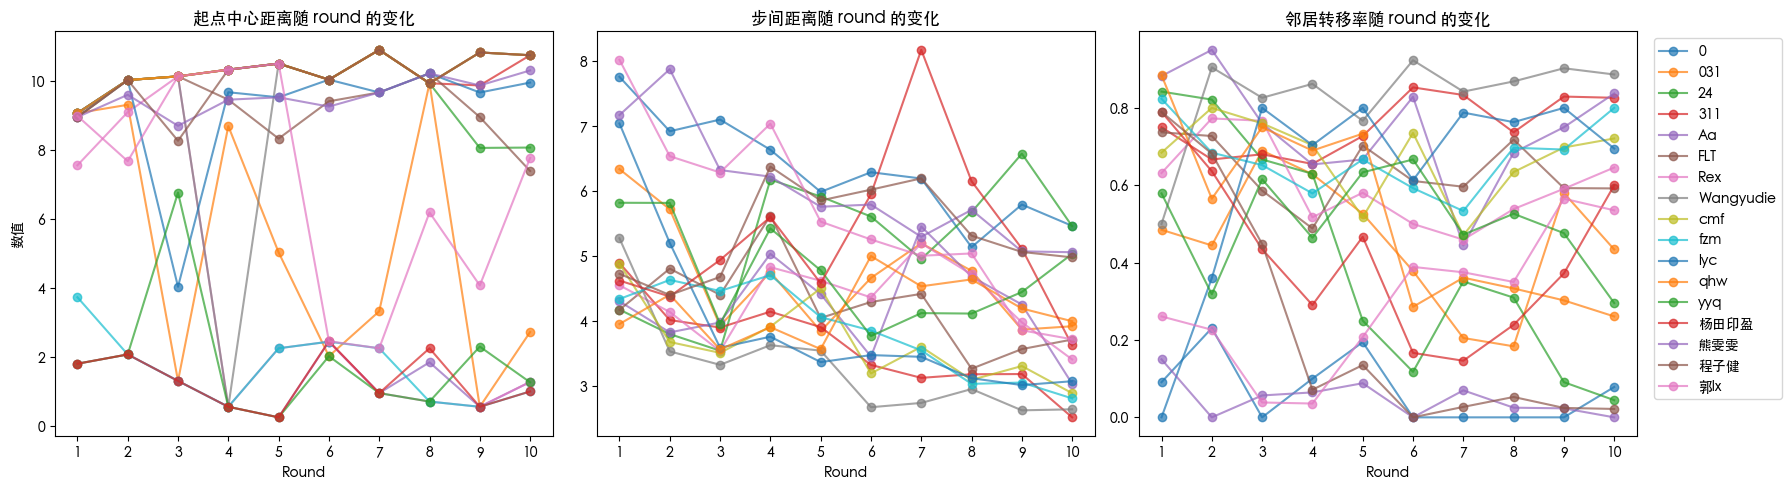

In [41]:
participants = sorted(analysis_df['participant'].unique())
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True)

for participant in participants:
    sub = analysis_df[analysis_df['participant'] == participant].sort_values('round_num')
    axes[0].plot(sub['round_num'], sub['start_dist_to_center'], marker='o', alpha=0.7, label=participant)
    axes[1].plot(sub['round_num'], sub['mean_step_dist'], marker='o', alpha=0.7, label=participant)
    axes[2].plot(sub['round_num'], sub['neighbor_transition_rate'], marker='o', alpha=0.7, label=participant)

axes[0].set_title('起点中心距离随 round 的变化')
axes[1].set_title('步间距离随 round 的变化')
axes[2].set_title('邻居转移率随 round 的变化')
axes[0].set_ylabel('数值')
for ax in axes:
    ax.set_xlabel('Round')
    ax.set_xticks(range(1, 11))
axes[2].legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

**图解释**

- 每条线代表一个被试在 10 个正式 round 上的策略轨迹。
- 如果同一个人的线大致比较平，说明这个人的策略比较稳定。
- 如果某个人的线明显上升或下降，说明这个人的策略会随着地图变化而系统性调整。
- 左图关注起手位置是否越来越偏中心或偏边缘。
- 中图关注这个人是否越来越倾向于远距离跳跃。
- 右图关注这个人是否越来越倾向于沿着相邻区域连续推进。

## 4. 地图层面：在同一张图上，不同被试是否一致

这里以 round 为单位，把所有被试放到同一张图上比较。
如果某个 round 的被试间标准差很小，说明这张图对大家施加了比较一致的策略约束。
如果标准差很大，说明这张图允许或诱发了更多个体差异。

In [42]:
round_consistency_df = (
    analysis_df.groupby(['round', 'round_num'], as_index=False)
    .agg(
        participants=('participant', 'nunique'),
        start_mean=('start_dist_to_center', 'mean'),
        start_sd=('start_dist_to_center', 'std'),
        step_mean=('mean_step_dist', 'mean'),
        step_sd=('mean_step_dist', 'std'),
        neighbor_mean=('neighbor_transition_rate', 'mean'),
        neighbor_sd=('neighbor_transition_rate', 'std'),
    )
    .sort_values('round_num')
    .reset_index(drop=True)
)

display(round_consistency_df.round(3))

,round,round_num,participants,start_mean,start_sd,step_mean,step_sd,neighbor_mean,neighbor_sd
0,1,1,17,7.345,2.945,5.410,1.345,0.581,0.290
1,2,2,17,7.887,3.377,4.920,1.251,0.576,0.269
2,3,3,17,7.299,3.786,4.412,1.131,0.561,0.275
3,4,4,17,6.636,4.650,5.160,1.081,0.479,0.265
4,5,5,17,7.152,4.312,4.603,0.895,0.510,0.241
5,6,6,17,6.774,3.845,4.526,1.142,0.451,0.313
6,7,7,17,6.873,4.555,4.774,1.341,0.410,0.264
7,8,8,17,7.201,4.087,4.387,1.080,0.451,0.284
8,9,9,17,6.447,4.571,4.174,1.067,0.488,0.301
9,10,10,17,6.847,4.283,3.843,1.003,0.487,0.311


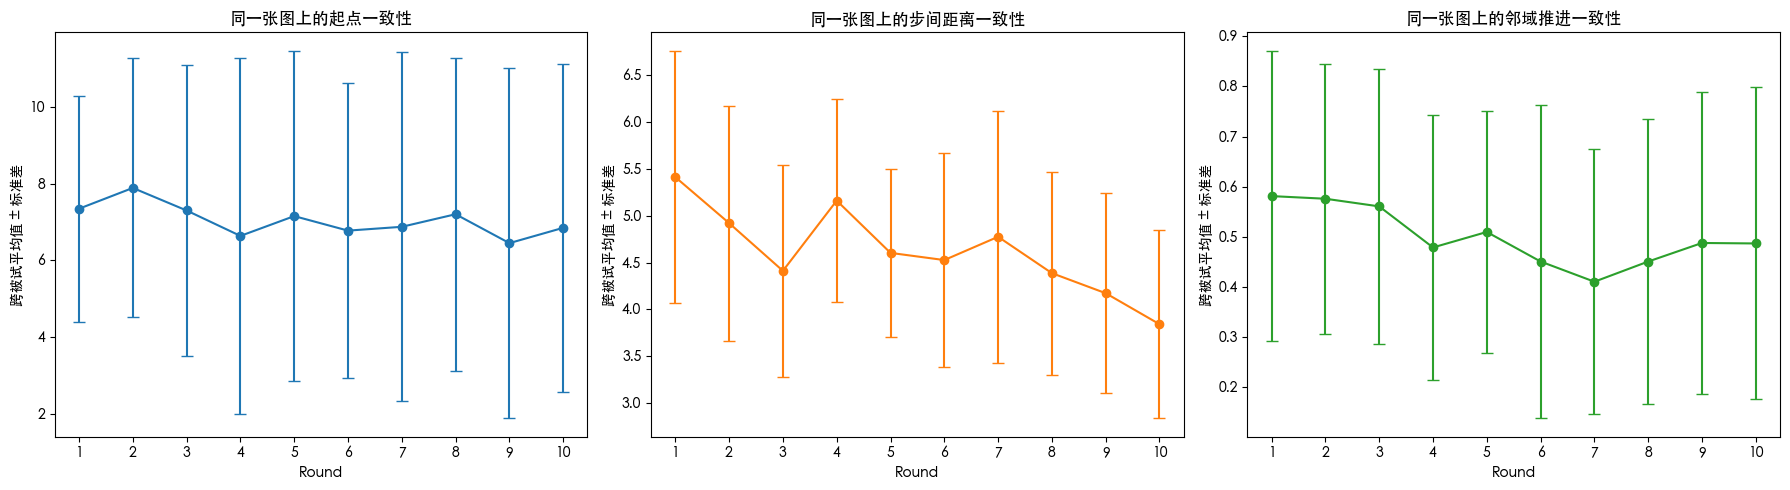

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True)

axes[0].errorbar(round_consistency_df['round_num'], round_consistency_df['start_mean'], yerr=round_consistency_df['start_sd'], fmt='o-', capsize=4)
axes[0].set_title('同一张图上的起点一致性')
axes[0].set_ylabel('跨被试平均值 ± 标准差')

axes[1].errorbar(round_consistency_df['round_num'], round_consistency_df['step_mean'], yerr=round_consistency_df['step_sd'], fmt='o-', capsize=4, color='tab:orange')
axes[1].set_title('同一张图上的步间距离一致性')
axes[1].set_ylabel('跨被试平均值 ± 标准差')

axes[2].errorbar(round_consistency_df['round_num'], round_consistency_df['neighbor_mean'], yerr=round_consistency_df['neighbor_sd'], fmt='o-', capsize=4, color='tab:green')
axes[2].set_title('同一张图上的邻域推进一致性')
axes[2].set_ylabel('跨被试平均值 ± 标准差')

for ax in axes:
    ax.set_xlabel('Round')
    ax.set_xticks(range(1, 11))

plt.tight_layout()
plt.show()

**图解释**

- 每个点表示一张特定地图上，所有被试的平均策略。
- 误差棒表示在这张图上，不同被试之间的差异大小。
- 如果误差棒短，说明这张图让大家表现得比较像。
- 如果误差棒长，说明这张图允许不同的人采用不同策略。
- 因此这组图回答的是“同一张地图会不会把大家的行为拉到一起”。

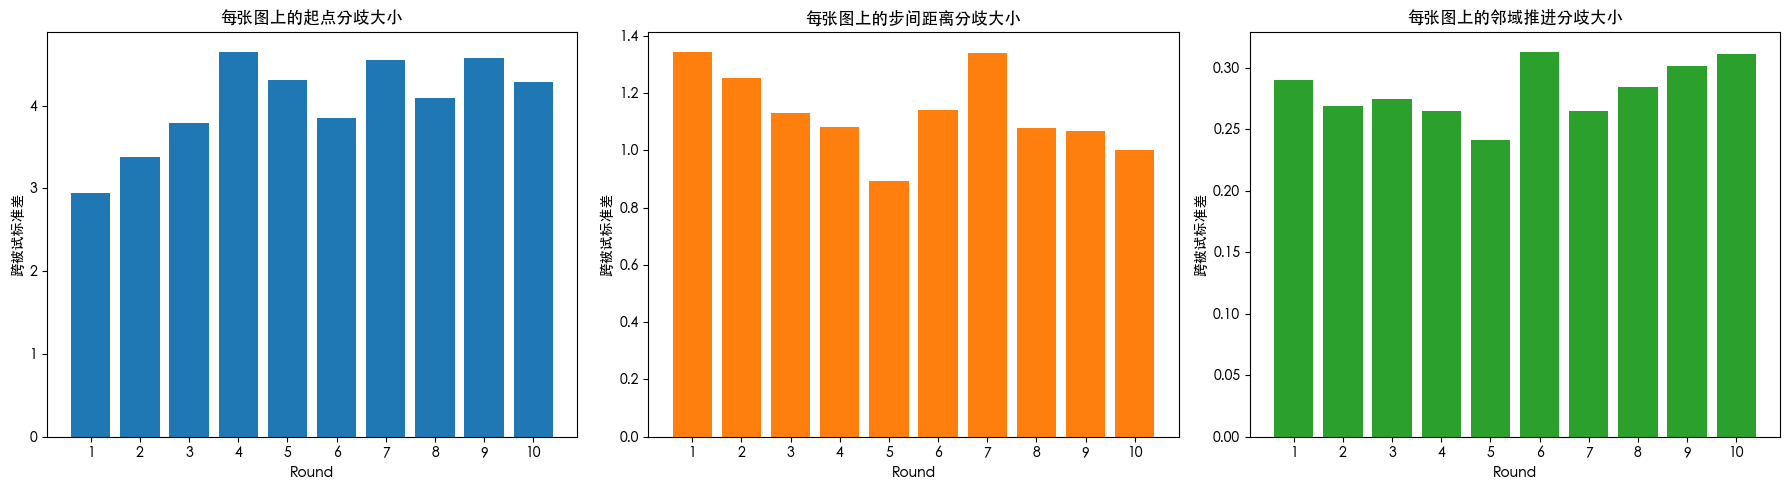

In [43]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True)

axes[0].bar(round_consistency_df['round_num'], round_consistency_df['start_sd'])
axes[0].set_title('每张图上的起点分歧大小')
axes[0].set_ylabel('跨被试标准差')

axes[1].bar(round_consistency_df['round_num'], round_consistency_df['step_sd'], color='tab:orange')
axes[1].set_title('每张图上的步间距离分歧大小')
axes[1].set_ylabel('跨被试标准差')

axes[2].bar(round_consistency_df['round_num'], round_consistency_df['neighbor_sd'], color='tab:green')
axes[2].set_title('每张图上的邻域推进分歧大小')
axes[2].set_ylabel('跨被试标准差')

for ax in axes:
    ax.set_xlabel('Round')
    ax.set_xticks(range(1, 11))

plt.tight_layout()
plt.show()

**图解释**

- 这三张柱状图只看“分歧大小”，不看平均值。
- 某个 round 的柱子越高，表示同一张图上不同被试越不一致。
- 这有助于识别哪些地图更像“强约束地图”，哪些地图更像“高自由度地图”。

## 5. 地图层面：图特征与策略平均水平的关系

这里先看 round 平均策略和图特征之间的关系，也就是：
- 哪类图会让大家平均上更偏中心起手
- 哪类图会让大家平均上走得更跳跃
- 哪类图会让大家平均上更沿邻域推进

In [44]:
round_level_df = round_consistency_df.merge(graph_df, on=['round', 'round_num'], how='left').sort_values('round_num').reset_index(drop=True)

graph_features = [
    'nodes', 'edges', 'density', 'degree_mean', 'degree_max',
    'diameter', 'avg_shortest_path', 'avg_local_clustering',
    'articulation_points', 'bridges', 'area_std', 'compactness_mean', 'center_dist_mean'
]
strategy_targets = {
    'start_mean': '起点中心距离',
    'step_mean': '平均步间距离',
    'neighbor_mean': '邻居转移率',
}

round_corr_rows = []
for metric in strategy_targets:
    for feature in graph_features:
        pearson_r, pearson_p = safe_pearson(round_level_df[feature], round_level_df[metric])
        spearman_rho, spearman_p = safe_spearman(round_level_df[feature], round_level_df[metric])
        round_corr_rows.append({
            'strategy_metric': metric,
            'graph_feature': feature,
            'pearson_r': pearson_r,
            'pearson_p': pearson_p,
            'spearman_rho': spearman_rho,
            'spearman_p': spearman_p,
            'abs_spearman': abs(spearman_rho) if not np.isnan(spearman_rho) else np.nan,
        })

round_corr_df = pd.DataFrame(round_corr_rows).sort_values(['strategy_metric', 'abs_spearman'], ascending=[True, False])
display(round_corr_df[['strategy_metric', 'graph_feature', 'pearson_r', 'spearman_rho', 'pearson_p', 'spearman_p']].round(3).head(18))

,strategy_metric,graph_feature,pearson_r,spearman_rho,pearson_p,spearman_p
36,neighbor_mean,area_std,0.741,0.794,0.014,0.006
31,neighbor_mean,diameter,-0.748,-0.698,0.013,0.025
26,neighbor_mean,nodes,-0.727,-0.661,0.017,0.038
27,neighbor_mean,edges,-0.718,-0.661,0.019,0.038
28,neighbor_mean,density,0.804,0.661,0.005,0.038
32,neighbor_mean,avg_shortest_path,-0.733,-0.661,0.016,0.038
37,neighbor_mean,compactness_mean,-0.726,-0.418,0.017,0.229
33,neighbor_mean,avg_local_clustering,0.491,0.406,0.150,0.244
38,neighbor_mean,center_dist_mean,-0.438,-0.358,0.205,0.310
30,neighbor_mean,degree_max,0.223,0.181,0.536,0.617


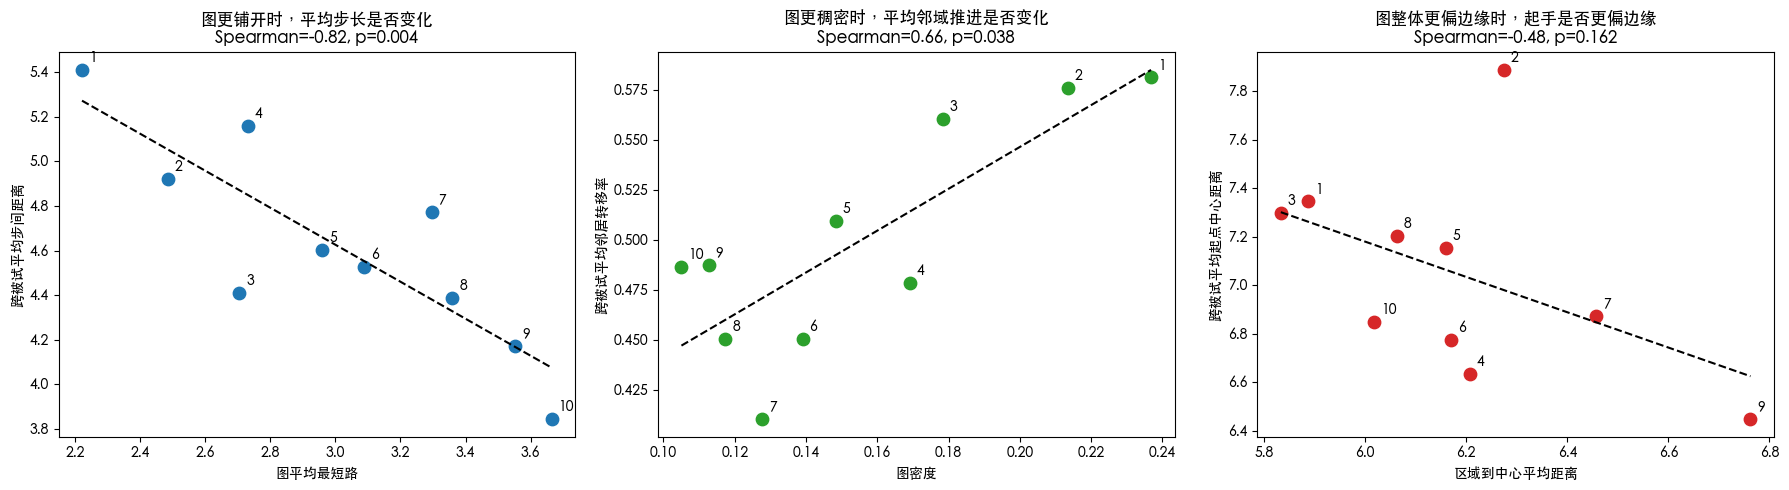

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

x1 = round_level_df['avg_shortest_path']
y1 = round_level_df['step_mean']
axes[0].scatter(x1, y1, s=80)
add_fit_line(axes[0], x1, y1)
for _, row in round_level_df.iterrows():
    axes[0].annotate(row['round'], (row['avg_shortest_path'], row['step_mean']), xytext=(5, 5), textcoords='offset points')
rho1, p1 = safe_spearman(x1, y1)
axes[0].set_xlabel('图平均最短路')
axes[0].set_ylabel('跨被试平均步间距离')
axes[0].set_title(f'图更铺开时，平均步长是否变化\nSpearman={rho1:.2f}, p={p1:.3f}')

x2 = round_level_df['density']
y2 = round_level_df['neighbor_mean']
axes[1].scatter(x2, y2, s=80, color='tab:green')
add_fit_line(axes[1], x2, y2)
for _, row in round_level_df.iterrows():
    axes[1].annotate(row['round'], (row['density'], row['neighbor_mean']), xytext=(5, 5), textcoords='offset points')
rho2, p2 = safe_spearman(x2, y2)
axes[1].set_xlabel('图密度')
axes[1].set_ylabel('跨被试平均邻居转移率')
axes[1].set_title(f'图更稠密时，平均邻域推进是否变化\nSpearman={rho2:.2f}, p={p2:.3f}')

x3 = round_level_df['center_dist_mean']
y3 = round_level_df['start_mean']
axes[2].scatter(x3, y3, s=80, color='tab:red')
add_fit_line(axes[2], x3, y3)
for _, row in round_level_df.iterrows():
    axes[2].annotate(row['round'], (row['center_dist_mean'], row['start_mean']), xytext=(5, 5), textcoords='offset points')
rho3, p3 = safe_spearman(x3, y3)
axes[2].set_xlabel('区域到中心平均距离')
axes[2].set_ylabel('跨被试平均起点中心距离')
axes[2].set_title(f'图整体更偏边缘时，起手是否更偏边缘\nSpearman={rho3:.2f}, p={p3:.3f}')

plt.tight_layout()
plt.show()

**图解释**

- 每个点是一张图。
- 横轴是图特征，纵轴是这张图上所有被试的平均策略。
- 如果点大致沿一条斜线分布，说明图特征和平均策略可能有关。
- 左图显示图的邻接网络更长时，被试更倾向于选择上一个选择附近的区域进行填色。
- 中图显示图的相邻关系更多时，被试更倾向于选择上一个选择的邻居进行填色。
- 右图显示图中更多区域分布在边缘时，被试更倾向于选择靠中心的位置开始填色。
- 标题中的 Spearman 相关系数主要反映单调关系方向和强弱。

## 6. 地图层面：控制个体基线后，图特征是否仍然影响策略

不同被试有自己的长期风格。为了避免“某人本来就喜欢跳得远”影响判断，
这里先对每个被试做去均值处理，再看图特征和策略偏移之间的关系。

In [34]:
centered_df = analysis_df.copy()
for col in ['start_dist_to_center', 'mean_step_dist', 'neighbor_transition_rate']:
    centered_df[f'{col}_pc'] = centered_df[col] - centered_df.groupby('participant')[col].transform('mean')

pc_pairs = [
    ('center_dist_mean', 'start_dist_to_center_pc', '区域到中心平均距离', '个体基线校正后的起点中心距离偏移'),
    ('avg_shortest_path', 'mean_step_dist_pc', '图平均最短路', '个体基线校正后的步间距离偏移'),
    ('density', 'neighbor_transition_rate_pc', '图密度', '个体基线校正后的邻居转移率偏移'),
]

pc_corr_rows = []
for feature, metric, _, _ in pc_pairs:
    pearson_r, pearson_p = safe_pearson(centered_df[feature], centered_df[metric])
    spearman_rho, spearman_p = safe_spearman(centered_df[feature], centered_df[metric])
    pc_corr_rows.append({
        'graph_feature': feature,
        'strategy_metric': metric,
        'pearson_r': pearson_r,
        'pearson_p': pearson_p,
        'spearman_rho': spearman_rho,
        'spearman_p': spearman_p,
    })

pc_corr_df = pd.DataFrame(pc_corr_rows)
display(pc_corr_df.round(3))

,graph_feature,strategy_metric,pearson_r,pearson_p,spearman_rho,spearman_p
0,center_dist_mean,start_dist_to_center_pc,-0.105,0.172,0.019,0.810
1,avg_shortest_path,mean_step_dist_pc,-0.451,0.000,-0.437,0.000
2,density,neighbor_transition_rate_pc,0.266,0.000,0.224,0.003


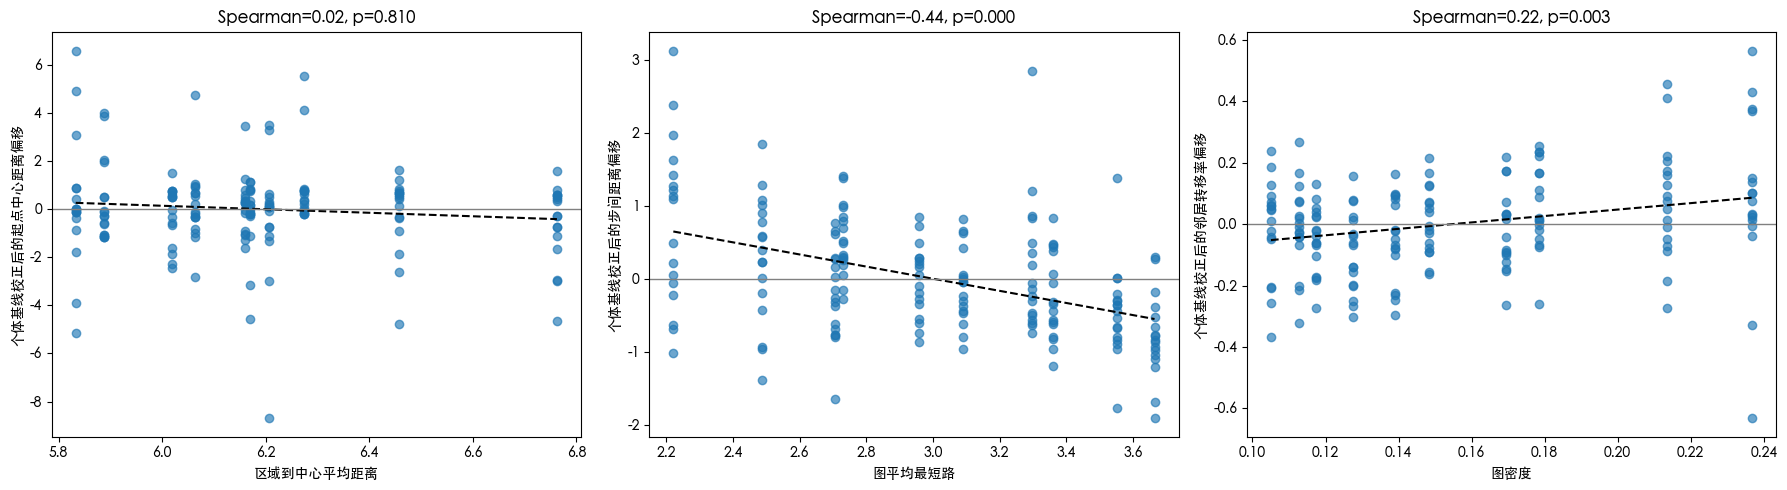

In [35]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (feature, metric, xlabel, ylabel) in zip(axes, pc_pairs):
    ax.scatter(centered_df[feature], centered_df[metric], alpha=0.65)
    add_fit_line(ax, centered_df[feature], centered_df[metric])
    rho, p = safe_spearman(centered_df[feature], centered_df[metric])
    ax.axhline(0, color='gray', linewidth=1)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(f'Spearman={rho:.2f}, p={p:.3f}')

plt.tight_layout()
plt.show()

**图解释**

- 这里每个点仍然是一条“被试 × round”记录。
- 但纵轴不再是原始策略值，而是“相对于这个人自己平均水平的偏移”。
- 如果某类图特征和这些偏移仍然有关，就更能说明是地图本身在推动策略变化，而不只是个体风格差异。
- 横线 `y=0` 表示“这个 round 的表现正好等于此人的平均水平”。
- 点越偏离这条线，说明这张图让这个人的行为偏离了自己的平时风格。

## 7. 地图层面：不同被试对图特征是否同样敏感

最后进一步问：
- 图更展开时，是否所有人都会更跳跃？
- 图更稠密时，是否所有人都会更沿邻域推进？
- 还是只有一部分人会对这些图特征敏感？

In [36]:
sensitivity_specs = [
    ('center_dist_mean', 'start_dist_to_center', '图整体更偏边缘 -> 起手是否更偏边缘'),
    ('avg_shortest_path', 'mean_step_dist', '图更展开 -> 是否更跳跃'),
    ('density', 'neighbor_transition_rate', '图更稠密 -> 是否更沿邻域推进'),
]

sensitivity_rows = []
for participant, sub in analysis_df.groupby('participant'):
    sub = sub.sort_values('round_num')
    for feature, metric, label in sensitivity_specs:
        rho, p = safe_spearman(sub[feature], sub[metric])
        sensitivity_rows.append({
            'participant': participant,
            'relation': label,
            'graph_feature': feature,
            'strategy_metric': metric,
            'spearman_rho': rho,
            'spearman_p': p,
        })

sensitivity_df = pd.DataFrame(sensitivity_rows)
display(sensitivity_df.round(3))

,participant,relation,graph_feature,strategy_metric,spearman_rho,spearman_p
0,0,图更展开 -> 是否更跳跃,avg_shortest_path,mean_step_dist,-0.915,0.000
1,0,图更稠密 -> 是否更沿邻域推进,density,neighbor_transition_rate,0.511,0.131
2,0,图整体更偏边缘 -> 起手是否更偏边缘,center_dist_mean,start_dist_to_center,0.503,0.138
3,031,图更展开 -> 是否更跳跃,avg_shortest_path,mean_step_dist,-0.527,0.117
4,031,图更稠密 -> 是否更沿邻域推进,density,neighbor_transition_rate,0.406,0.244
5,031,图整体更偏边缘 -> 起手是否更偏边缘,center_dist_mean,start_dist_to_center,-0.103,0.777
6,24,图更展开 -> 是否更跳跃,avg_shortest_path,mean_step_dist,0.527,0.117
7,24,图更稠密 -> 是否更沿邻域推进,density,neighbor_transition_rate,0.903,0.000
8,24,图整体更偏边缘 -> 起手是否更偏边缘,center_dist_mean,start_dist_to_center,0.115,0.751
9,311,图更展开 -> 是否更跳跃,avg_shortest_path,mean_step_dist,-0.891,0.001


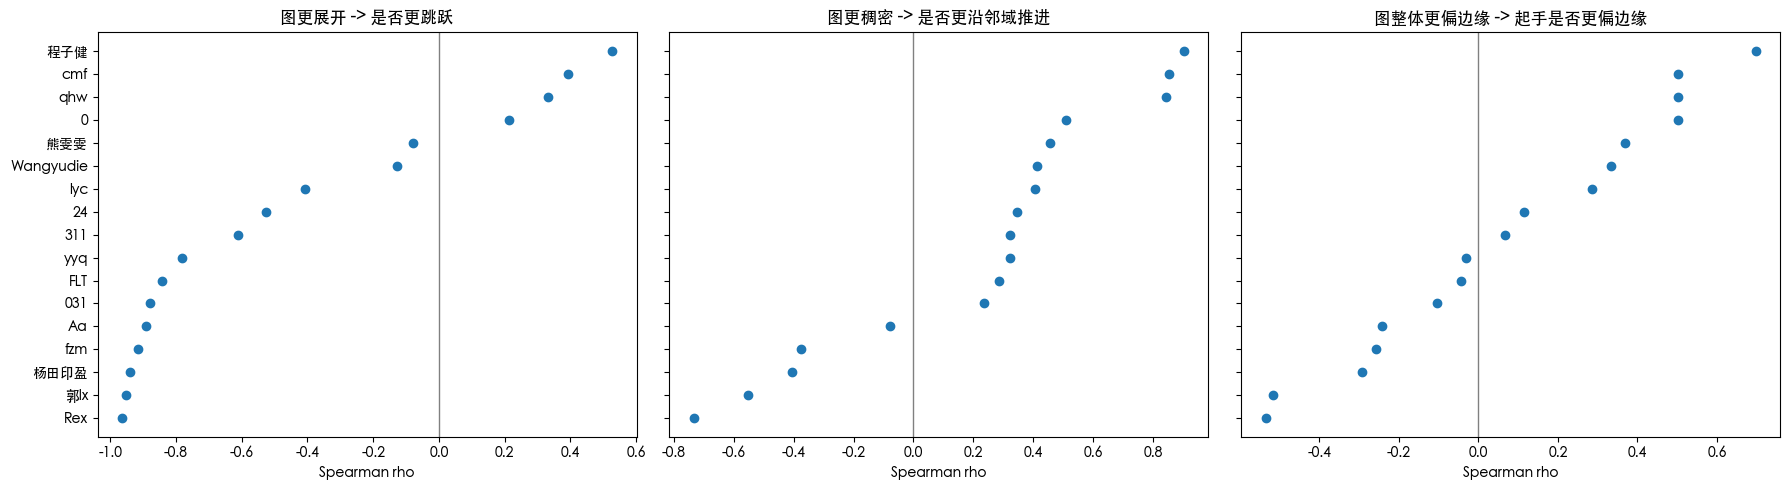

In [37]:
relations = [spec[2] for spec in sensitivity_specs]
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, relation in zip(axes, relations):
    sub = sensitivity_df[sensitivity_df['relation'] == relation].sort_values('spearman_rho')
    y = np.arange(len(sub))
    ax.axvline(0, color='gray', linewidth=1)
    ax.scatter(sub['spearman_rho'], y)
    ax.set_yticks(y)
    ax.set_yticklabels(sub['participant'])
    ax.set_xlabel('Spearman rho')
    ax.set_title(relation)

plt.tight_layout()
plt.show()

**图解释**

- 这三张图里，每个点代表一个被试，而不是一张图。
- 横轴是该被试在 10 个 round 内，对某一“图特征 -> 策略”关系的相关系数。
- 如果大多数点都在 0 的同一侧，说明大多数被试对这类图特征的反应方向一致。
- 如果点分散在 0 两边，说明不同人对同一种图特征的反应方向不一致。
- 这一步能帮助区分“总体平均关系”到底是普遍现象，还是少数被试驱动的。

## 8. 快速结论表

In [38]:
participant_spread = participant_profile_df[['avg_start_dist', 'avg_mean_step_dist', 'avg_neighbor_rate']].agg(['mean', 'std']).T
participant_spread.columns = ['across_participants_mean', 'across_participants_std']

top_round_corr = (
    round_corr_df.sort_values('abs_spearman', ascending=False)
    .groupby('strategy_metric', as_index=False)
    .head(5)
)

print('不同被试平均策略的离散程度')
display(participant_spread.round(3))

print('各被试跨 round 稳定性摘要')
display(stability_df.round(3))

print('同一张图上的跨被试一致性摘要')
display(round_consistency_df.round(3))

print('图特征与平均策略关系最强的结果')
display(top_round_corr[['strategy_metric', 'graph_feature', 'pearson_r', 'spearman_rho', 'pearson_p', 'spearman_p']].round(3))

不同被试平均策略的离散程度


,across_participants_mean,across_participants_std
avg_start_dist,7.046,3.655
avg_mean_step_dist,4.621,0.887
avg_neighbor_rate,0.499,0.232


各被试跨 round 稳定性摘要


,participant,start_sd,step_sd,neighbor_sd,start_round_rho,step_round_rho,neighbor_round_rho,start_round_p,step_round_p,neighbor_round_p
0,0,0.545,0.792,0.086,0.600,-0.915,-0.511,0.067,0.000,0.131
1,031,3.693,0.855,0.166,-0.370,-0.527,-0.406,0.293,0.117,0.244
2,24,0.982,1.033,0.304,-0.297,0.527,-0.903,0.405,0.117,0.000
3,311,0.516,0.677,0.075,0.297,-0.891,0.552,0.405,0.001,0.098
4,Aa,0.729,0.718,0.143,-0.243,-0.079,-0.321,0.498,0.829,0.365
5,FLT,0.884,0.666,0.082,-0.309,-0.612,-0.345,0.385,0.060,0.328
6,Rex,3.811,0.568,0.106,-0.644,-0.127,-0.321,0.044,0.726,0.365
7,Wangyudie,3.109,0.803,0.124,0.600,-0.842,0.406,0.067,0.002,0.244
8,cmf,0.545,0.627,0.105,0.600,-0.782,-0.285,0.067,0.008,0.425
9,fzm,1.036,0.704,0.091,-0.463,-0.879,0.079,0.177,0.001,0.829


同一张图上的跨被试一致性摘要


,round,round_num,participants,start_mean,start_sd,step_mean,step_sd,neighbor_mean,neighbor_sd
0,1,1,17,7.345,2.945,5.410,1.345,0.581,0.290
1,2,2,17,7.887,3.377,4.920,1.251,0.576,0.269
2,3,3,17,7.299,3.786,4.412,1.131,0.561,0.275
3,4,4,17,6.636,4.650,5.160,1.081,0.479,0.265
4,5,5,17,7.152,4.312,4.603,0.895,0.510,0.241
5,6,6,17,6.774,3.845,4.526,1.142,0.451,0.313
6,7,7,17,6.873,4.555,4.774,1.341,0.410,0.264
7,8,8,17,7.201,4.087,4.387,1.080,0.451,0.284
8,9,9,17,6.447,4.571,4.174,1.067,0.488,0.301
9,10,10,17,6.847,4.283,3.843,1.003,0.487,0.311


图特征与平均策略关系最强的结果


,strategy_metric,graph_feature,pearson_r,spearman_rho,pearson_p,spearman_p
14,step_mean,edges,-0.820,-0.818,0.004,0.004
13,step_mean,nodes,-0.826,-0.818,0.003,0.004
15,step_mean,density,0.806,0.818,0.005,0.004
19,step_mean,avg_shortest_path,-0.843,-0.818,0.002,0.004
36,neighbor_mean,area_std,0.741,0.794,0.014,0.006
18,step_mean,diameter,-0.726,-0.767,0.017,0.010
31,neighbor_mean,diameter,-0.748,-0.698,0.013,0.025
5,start_mean,diameter,-0.694,-0.673,0.026,0.033
32,neighbor_mean,avg_shortest_path,-0.733,-0.661,0.016,0.038
28,neighbor_mean,density,0.804,0.661,0.005,0.038


## 9. 如何读这份 notebook

如果你要写报告，建议按下面顺序组织：

1. 先看被试层面的平均策略差异。
   这回答“人和人是不是本来就不一样”。

2. 再看同一被试跨 round 的稳定性。
   这回答“这个人有没有稳定风格，还是会随地图变化而明显漂移”。

3. 然后看同一张图上的跨被试一致性。
   这回答“地图本身会不会把不同的人拉向相似行为”。

4. 最后看图特征与策略的关系。
   这回答“到底是图的哪些结构在推动策略变化”。